Base geral tratada carregada com sucesso.
Total de registros: 1020
Período: 2023-07-01 a 2026-04-15
Valores ausentes por coluna após tratamento:
Visualizações                 0
fim_de_semana                 0
recesso_judiciario            0
feriado_nacional_fixo         0
carnaval                      0
quarta_cinzas                 0
sexta_paixao                  0
corpus_christi                0
data_especifica_judiciario    0
ponto_facultativo_emenda      0
dtype: int64
Separação treino/teste e escalonamento realizados.

Melhor configuração encontrada:
Ordem: (1, 1, 2)
Ordem sazonal: (1, 0, 1, 7)
AIC: 102.23


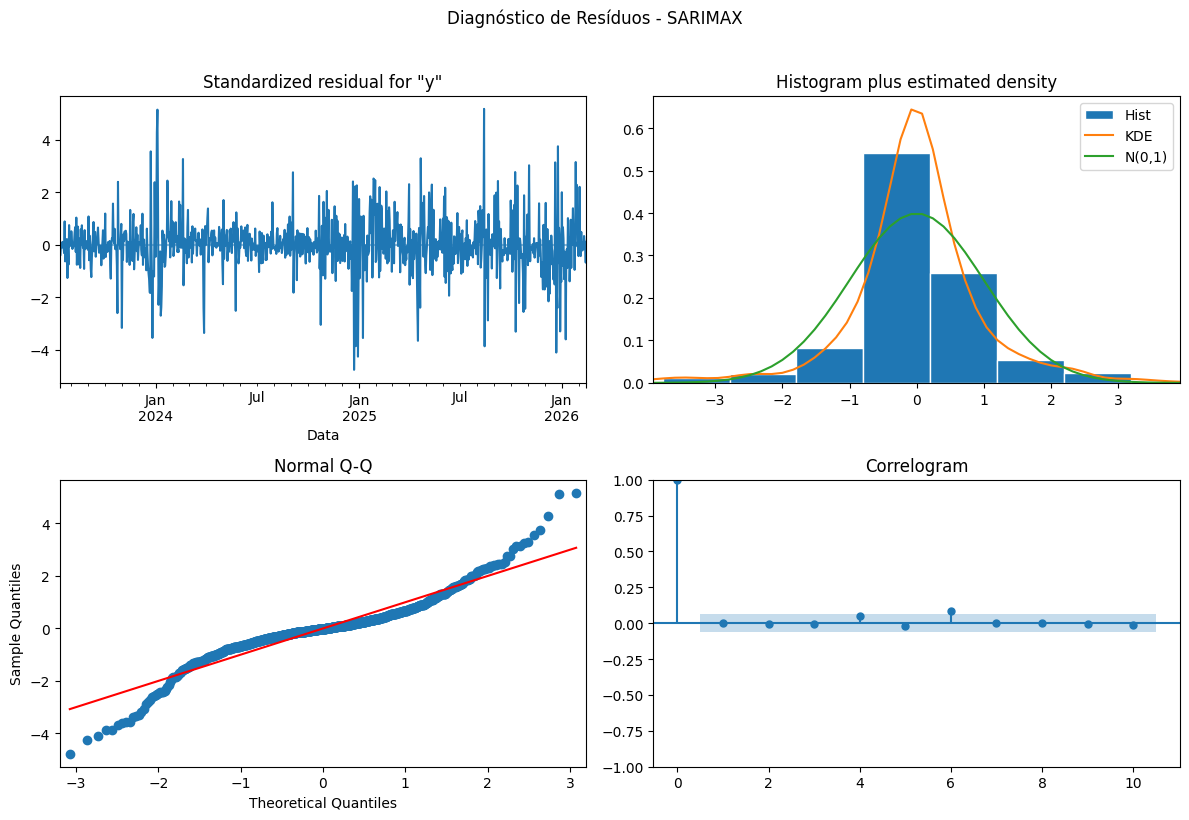

Previsão e reversão de escala concluídas.
AVALIAÇÃO SARIMAX - ÚLTIMOS 60 DIAS
Ordem: (1, 1, 2)
Ordem sazonal: (1, 0, 1, 7)
RMSE: 4311.73
MAE : 2686.48
MAPE: 18.72%
R²  : 0.9303


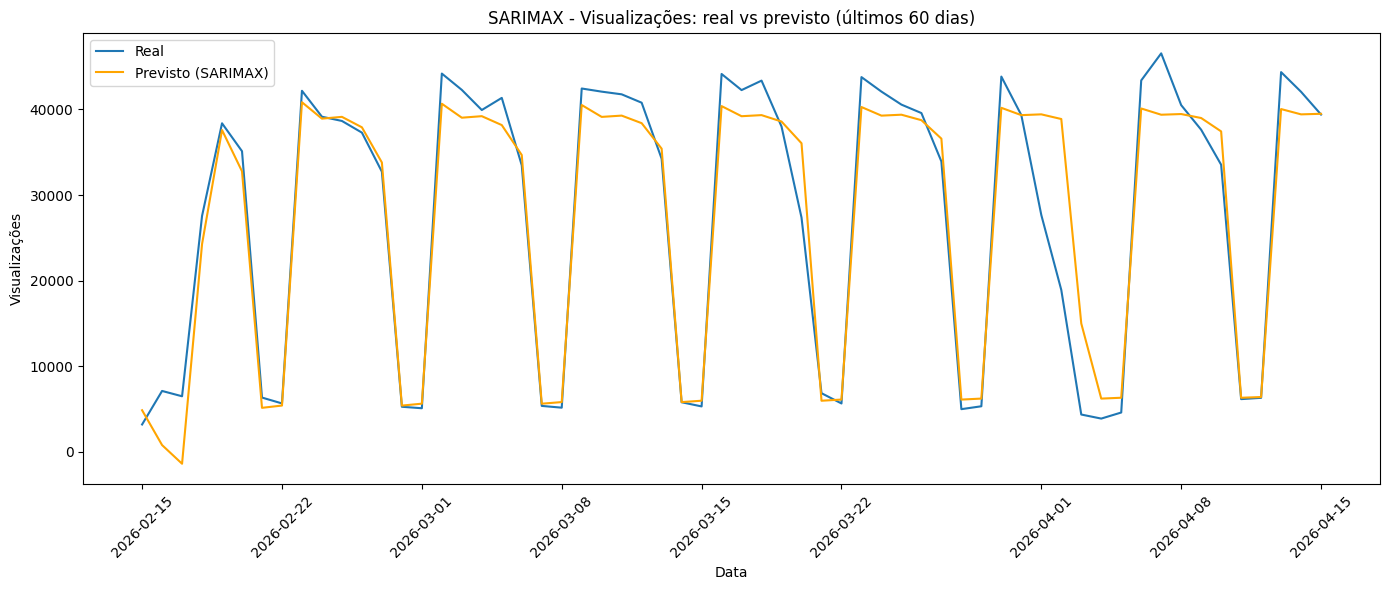

Arquivos salvos com sucesso.


In [3]:
# %%
# ## 1. Geração da base específica para o SARIMAX
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

df = pd.read_csv("../dados/trafego_tratado.csv")

df["Data"] = pd.to_datetime(df["Data"])
df = df.sort_values("Data").reset_index(drop=True)

print("Base geral tratada carregada com sucesso.")
print(f"Total de registros: {len(df)}")
print(f"Período: {df['Data'].min().date()} a {df['Data'].max().date()}")

# %% [markdown]
# ## 2. Seleção da série temporal e dos regressores externos
colunas_exog = [
    "fim_de_semana",
    "recesso_judiciario",
    "feriado_nacional_fixo",
    "carnaval",
    "quarta_cinzas",
    "sexta_paixao",
    "corpus_christi",
    "data_especifica_judiciario",
    "ponto_facultativo_emenda"
]

df_sarimax = df[["Data", "Visualizações"] + colunas_exog].copy()
df_sarimax = df_sarimax.set_index("Data")

# Imposição da frequência diária e tratamento explícito de possíveis falhas (dias ausentes)
df_sarimax = df_sarimax.asfreq("D")

# Tratamento de Nulos gerados pelo asfreq
# Exógenas recebem 0 (assumindo que o dia faltante não é feriado/recesso previamente mapeado)
df_sarimax[colunas_exog] = df_sarimax[colunas_exog].fillna(0)
# Variável alvo recebe interpolação linear
df_sarimax["Visualizações"] = df_sarimax["Visualizações"].interpolate(method="linear")

print("Valores ausentes por coluna após tratamento:")
print(df_sarimax.isna().sum())

# %% [markdown]
# ## 3. Separação temporal entre treino e teste e Escalonamento
dias_teste = 60

y = df_sarimax["Visualizações"]
X = df_sarimax[colunas_exog]

y_train = y.iloc[:-dias_teste]
y_test = y.iloc[-dias_teste:]

X_train = X.iloc[:-dias_teste]
X_test = X.iloc[-dias_teste:]

# Escalonamento da variável alvo para evitar ConvergenceWarning no statsmodels
scaler = StandardScaler()
y_train_scaled = pd.Series(
    scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten(), 
    index=y_train.index
)

print("Separação treino/teste e escalonamento realizados.")

# %% [markdown]
# ## 4. Ajuste de hiperparâmetros do SARIMAX (Com Diferenciação)
# Inclusão de ordens com d=1 para modelar possíveis tendências não estacionárias
ordens = [
    (1, 0, 1), (1, 1, 1),
    (2, 0, 1), (2, 1, 1),
    (1, 0, 2), (1, 1, 2)
]

ordens_sazonais = [
    (0, 0, 0, 0),
    (1, 0, 0, 7),
    (0, 0, 1, 7),
    (1, 0, 1, 7)
]

melhor_aic = np.inf
melhor_ordem = None
melhor_ordem_sazonal = None
melhor_modelo = None

for ordem in ordens:
    for ordem_sazonal in ordens_sazonais:
        try:
            modelo = SARIMAX(
                y_train_scaled,  # Utilizando a série escalonada
                exog=X_train,
                order=ordem,
                seasonal_order=ordem_sazonal,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            resultado = modelo.fit(disp=False, maxiter=300)

            if resultado.aic < melhor_aic:
                melhor_aic = resultado.aic
                melhor_ordem = ordem
                melhor_ordem_sazonal = ordem_sazonal
                melhor_modelo = resultado

        except Exception as e:
            pass # Silenciado para reduzir poluição no console durante o grid search

print("\nMelhor configuração encontrada:")
print(f"Ordem: {melhor_ordem}")
print(f"Ordem sazonal: {melhor_ordem_sazonal}")
print(f"AIC: {melhor_aic:.2f}")

# %% [markdown]
# ## 5. Diagnóstico de Resíduos
# Análise fundamental para atestar se o modelo capturou todo o sinal da série (os resíduos devem parecer ruído branco).
melhor_modelo.plot_diagnostics(figsize=(12, 8))
plt.suptitle("Diagnóstico de Resíduos - SARIMAX", y=1.02)
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 6. Previsão no conjunto de teste e Reversão do Escalonamento
previsao_sarimax_scaled = melhor_modelo.get_forecast(
    steps=dias_teste,
    exog=X_test
)

# Revertendo a previsão para a escala original de Visualizações
y_pred_scaled_values = previsao_sarimax_scaled.predicted_mean.values.reshape(-1, 1)
y_pred_sarimax_values = scaler.inverse_transform(y_pred_scaled_values).flatten()

y_pred_sarimax = pd.Series(y_pred_sarimax_values, index=y_test.index)

print("Previsão e reversão de escala concluídas.")

# %% [markdown]
# ## 7. Avaliação do SARIMAX
def calcular_mape(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mascara = y_true != 0
    return np.mean(np.abs((y_true[mascara] - y_pred[mascara]) / y_true[mascara])) * 100

# Métricas calculadas sobre os valores na grandeza original
rmse_sarimax = np.sqrt(mean_squared_error(y_test, y_pred_sarimax))
mae_sarimax = mean_absolute_error(y_test, y_pred_sarimax)
mape_sarimax = calcular_mape(y_test, y_pred_sarimax)
r2_sarimax = r2_score(y_test, y_pred_sarimax)

print("=" * 60)
print("AVALIAÇÃO SARIMAX - ÚLTIMOS 60 DIAS")
print("=" * 60)
print(f"Ordem: {melhor_ordem}")
print(f"Ordem sazonal: {melhor_ordem_sazonal}")
print(f"RMSE: {rmse_sarimax:.2f}")
print(f"MAE : {mae_sarimax:.2f}")
print(f"MAPE: {mape_sarimax:.2f}%")
print(f"R²  : {r2_sarimax:.4f}")

# %% [markdown]
# ## 8. Visualização dos valores reais e previstos
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test.values, label="Real")
plt.plot(y_test.index, y_pred_sarimax.values, label="Previsto (SARIMAX)", color='orange')

plt.title("SARIMAX - Visualizações: real vs previsto (últimos 60 dias)")
plt.xlabel("Data")
plt.ylabel("Visualizações")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 9. Salvamento das métricas e previsões do SARIMAX
metricas_sarimax = pd.DataFrame({
    "modelo": ["SARIMAX"],
    "ordem": [str(melhor_ordem)],
    "ordem_sazonal": [str(melhor_ordem_sazonal)],
    "rmse": [rmse_sarimax],
    "mae": [mae_sarimax],
    "mape": [mape_sarimax],
    "r2": [r2_sarimax]
})

metricas_sarimax.to_csv("../dados/metricas_sarimax.csv", index=False)

previsao_sarimax_df = pd.DataFrame({
    "Data": y_test.index,
    "real": y_test.values,
    "previsto_sarimax": y_pred_sarimax.values
})

previsao_sarimax_df["erro"] = previsao_sarimax_df["real"] - previsao_sarimax_df["previsto_sarimax"]
previsao_sarimax_df["erro_absoluto"] = abs(previsao_sarimax_df["erro"])
previsao_sarimax_df["erro_percentual_abs"] = (previsao_sarimax_df["erro_absoluto"] / previsao_sarimax_df["real"]) * 100

previsao_sarimax_df.to_csv("../dados/previsao_sarimax_visualizacoes.csv", index=False)

print("Arquivos salvos com sucesso.")